# Binary SNP PCR peak analysis

This notebook generates the binary amplification plots used in Fig. 1D.

## Input

Input files are CSV tables containing peak values for the four nucleotides (`A`, `T`, `G`, `C`) for each assay.

Expected input files:
- `data/U2OS_peaks.csv`
- `data/T47D_peaks.csv`

## Analysis

For each dataset:
1. Peak values are normalised by the maximum value within each row.
2. Signals are binarised using a threshold of 0.05.
3. Each nucleotide is classified as:
   - **Allele-specific**
   - **False positive**
   - **False negative**
   - **Not amplified**
4. Binary amplification status is visualised as a heatmap-like tile plot.

## Output

The notebook saves:
- `U2OS.pdf`
- `T47D.pdf`

These panels were combined and annotated using BioRender for final figure presentation.

In [1]:
#library
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(showtext)
  library(sysfonts)
})

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )

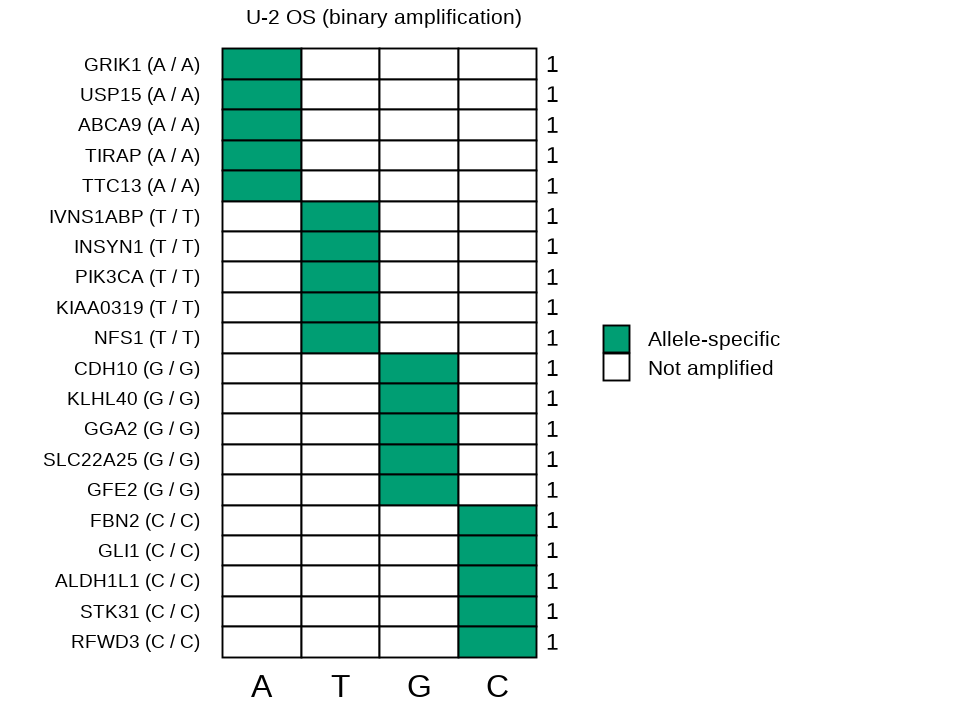

In [2]:
#input
options(repr.plot.width = 8, repr.plot.height =6) 
PCR_data <- "data/U2OS_peaks.csv"

df <- read.csv(PCR_data)

#add alleles for each gene
df$allele1 <- c("A", "A", "A", "A", "A",
                 "T", "T", "T", "T", "T",
                 "G", "G", "G", "G", "G",
                 "C", "C", "C", "C", "C")

df$allele2 <- c("A", "A", "A", "A", "A",
                 "T", "T", "T", "T", "T",
                 "G", "G", "G", "G", "G",
                 "C", "C", "C", "C", "C")

#combine alleles with $Genes
df$Genes <- paste0(df$Genes, " (", df$allele1, " / ", df$allele2, ")")

#normalise by the max value per row
df_norm <- df %>%
  rowwise() %>%
  mutate(
    row_max = max(c(A, T, G, C), na.rm = TRUE),
    A = A / row_max,
    T = T / row_max,
    G = G / row_max,
    C = C / row_max
  ) %>%
  select(-row_max) %>%
  ungroup()


# Binarise (threshold)
thr <- 0.05
num_cols <- c("A", "T", "G", "C")

df_bin <- df_norm %>%
  mutate(across(all_of(num_cols), ~ ifelse(.x >= thr, 1, 0)))

# Convert to long format
df_long <- df_bin %>%
  pivot_longer(
    cols = all_of(num_cols),
    names_to = "Nucleotide",
    values_to = "Value"
  )

#Number of "amplified"
amp_count <- df_bin %>%
  rowwise() %>%
  mutate(n_amplified = sum(c_across(A:C))) %>%
  ungroup() %>%
  select(Genes, n_amplified)

df_long <- df_long %>%
  left_join(amp_count, by = "Genes")



# Maintain order
df_long$Genes <- factor(df_long$Genes, levels = rev(unique(df_long$Genes)))
df_long$Nucleotide <- factor(df_long$Nucleotide, levels = c("A", "T", "G", "C"))

df_long <- df_long %>%
  mutate(
    is_target = (Nucleotide == allele1 | Nucleotide == allele2),

    tile_type = case_when(
      # Correct amplification
      Value == 1 & is_target                     ~ "Allele-specific",

      # False positive: amplified but not target
      Value == 1 & !is_target                    ~ "False positive",

      # False negative: target but not amplified
      Value == 0 & is_target                     ~ "False negative",

      # True negative: non-target and not amplified
      TRUE                                       ~ "Not amplified"
    )
  )

df_long$tile_type <- factor(
  df_long$tile_type,
  levels = c("Allele-specific",
             "False positive",
             "False negative",
             "Not amplified")
)

# ---- Plot ----
ggplot(df_long, aes(x = Nucleotide, y = Genes, fill = tile_type)) +
  geom_tile(color = "black", linewidth = 0.4) +

  # Add amplification count to right side
  geom_text(
    data = distinct(df_long, Genes, n_amplified),
    aes(x = 4.7, y = Genes, label = n_amplified),
    inherit.aes = FALSE,
    size = 6
  ) +

  scale_fill_manual(
  values = c(
    "Allele-specific"= "#009E73",
    "False positive" = "#D55E00",
    "False negative" = "#56B4E9",  
    "Not amplified"  = "white"
  ),
  name = NULL
) +

  coord_cartesian(clip = "off") +

  labs(
    title = "U-2 OS (binary amplification)",
    x = NULL,
    y = NULL
  ) +

  theme_minimal(base_size = 20) +
  theme(
    axis.text.x   = element_text(size = 24, color = "black"),
    axis.text.y   = element_text(size = 14, color = "black"),
    plot.title    = element_text(size = 16, hjust = 0.5),
    panel.grid    = element_blank(),
    legend.text   = element_text(color = "black"),
    plot.margin   = margin(5.5, 80, 5.5, 5.5)
  )

In [3]:
ggsave("U2OS.pdf", plot = last_plot(), width = 8, height = 6, units = "in")

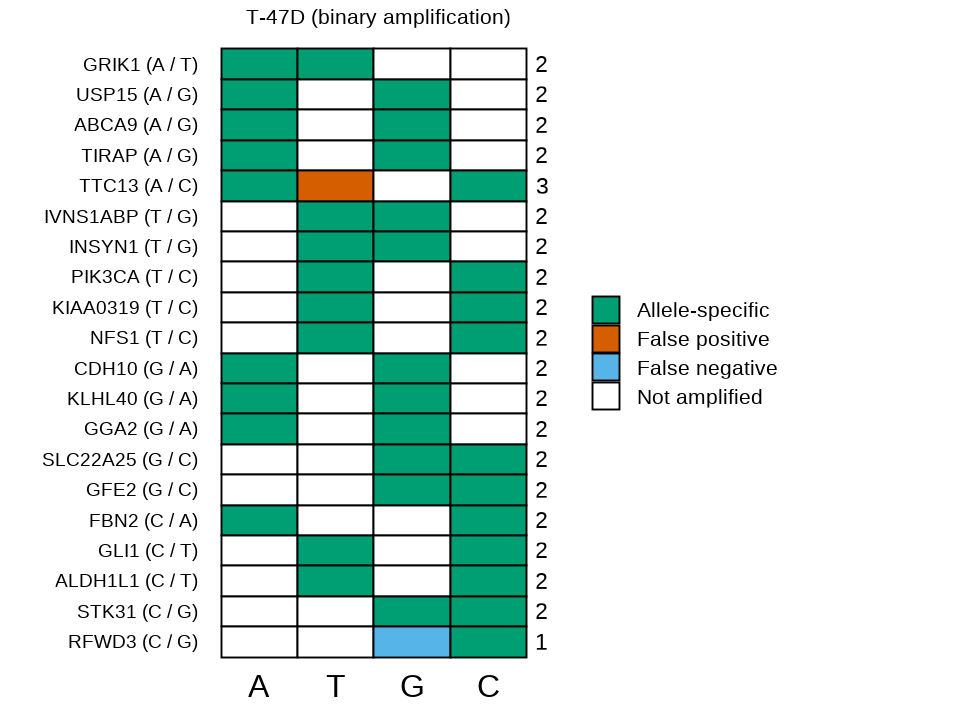

In [4]:
# T47D (divide values by the maximum of each row)
options(repr.plot.width = 8, repr.plot.height =6) 
PCR_data <- "data/T47D_peaks.csv"

df <- read.csv(PCR_data)

#add alleles for each gene
df$allele1 <- c("A", "A", "A", "A", "A",
                 "T", "T", "T", "T", "T",
                 "G", "G", "G", "G", "G",
                 "C", "C", "C", "C", "C")

df$allele2 <- c("T", "G", "G", "G", "C",
                 "G", "G", "C", "C", "C",
                 "A", "A", "A", "C", "C",
                 "A", "T", "T", "G", "G")

#combine alleles with $Genes
df$Genes <- paste0(df$Genes, " (", df$allele1, " / ", df$allele2, ")")

#normalise by the max value per row
df_norm <- df %>%
  rowwise() %>%
  mutate(
    row_max = max(c(A, T, G, C), na.rm = TRUE),
    A = A / row_max,
    T = T / row_max,
    G = G / row_max,
    C = C / row_max
  ) %>%
  select(-row_max) %>%
  ungroup()

# ... your code up to df_norm creation stays the same ...

# Binarise (threshold)
thr <- 0.05
num_cols <- c("A", "T", "G", "C")

df_bin <- df_norm %>%
  mutate(across(all_of(num_cols), ~ ifelse(.x >= thr, 1, 0)))

# Convert to long format
df_long <- df_bin %>%
  pivot_longer(
    cols = all_of(num_cols),
    names_to = "Nucleotide",
    values_to = "Value"
  )

#Number of "amplified"
amp_count <- df_bin %>%
  rowwise() %>%
  mutate(n_amplified = sum(c_across(A:C))) %>%
  ungroup() %>%
  select(Genes, n_amplified)

df_long <- df_long %>%
  left_join(amp_count, by = "Genes")



# Maintain order
df_long$Genes <- factor(df_long$Genes, levels = rev(unique(df_long$Genes)))
df_long$Nucleotide <- factor(df_long$Nucleotide, levels = c("A", "T", "G", "C"))

df_long <- df_long %>%
  mutate(
    is_target = (Nucleotide == allele1 | Nucleotide == allele2),

    tile_type = case_when(
      # Correct amplification
      Value == 1 & is_target                     ~ "Allele-specific",

      # False positive: amplified but not target
      Value == 1 & !is_target                    ~ "False positive",

      # False negative: target but not amplified
      Value == 0 & is_target                     ~ "False negative",

      # True negative: non-target and not amplified
      TRUE                                       ~ "Not amplified"
    )
  )

df_long$tile_type <- factor(
  df_long$tile_type,
  levels = c("Allele-specific",
             "False positive",
             "False negative",
             "Not amplified")
)

# ---- Plot ----
ggplot(df_long, aes(x = Nucleotide, y = Genes, fill = tile_type)) +
  geom_tile(color = "black", linewidth = 0.4) +

  # Add amplification count to right side
  geom_text(
    data = distinct(df_long, Genes, n_amplified),
    aes(x = 4.7, y = Genes, label = n_amplified),
    inherit.aes = FALSE,
    size = 6
  ) +

  scale_fill_manual(
  values = c(
    "Allele-specific"= "#009E73",
    "False positive" = "#D55E00",
    "False negative" = "#56B4E9",  
    "Not amplified"  = "white"
  ),
  name = NULL
) +

  coord_cartesian(clip = "off") +

  labs(
    title = "T-47D (binary amplification)",
    x = NULL,
    y = NULL
  ) +

  theme_minimal(base_size = 20) +
  theme(
    axis.text.x   = element_text(size = 24, color = "black"),
    axis.text.y   = element_text(size = 14, color = "black"),
    plot.title    = element_text(size = 16, hjust = 0.5),
    panel.grid    = element_blank(),
    legend.text   = element_text(color = "black"),
    plot.margin   = margin(5.5, 80, 5.5, 5.5)
  )

In [5]:
ggsave("T47D.pdf", plot = last_plot(), width = 8, height = 6, units = "in")

In [6]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] showtext_0.9-7 showtextdb_3.0 sysfonts_0.8.9 tidyr_1.3.1    dplyr_1.1.4   
[6] ggplot2_3.5.2 

loaded via a namespace (and not attached):
 [1] crayon_1.5.3       vctrs_0.6.5        cli_3.6.5          rlang_1.1.6       
 [5] purrr_1.1.0        generics_0.1.4     Cairo_1.6-3        textshaping_1.0.0 
 [9] jso